In [ ]:
# Goal: Identify how crash patterns vary by location, time, and crash type in Chicago.

In [1]:
# Import dataset
import pandas as pd

df = pd.read_csv("/Users/danielnguyen/PycharmProjects/chicagocrashsites/Traffic_Crashes.csv")

print(df.shape)
print(df.head())
print(df.info())

/var/folders/91/v0jvjkt15xz3g9xj81_fbps40000gn/T/ipykernel_54862/3170099242.py:4: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/danielnguyen/PycharmProjects/chicagocrashsites/Traffic_Crashes.csv")


(1021279, 48)
                                     CRASH_RECORD_ID CRASH_DATE_EST_I  \
0  da3f926cddcd4aa09faf08017ab994f4de0d5c1727459f...              NaN   
1  d6a0b1b2bd800c24121d3636bbbecf9a82e1d2b9f541e3...              NaN   
2  b05308eae47628a3fe5d3702ea1afa673d534c5d63a542...              NaN   
3  e623d37063874d231013372558d50728118cb306f05243...              NaN   
4  53dac31b1e61ee502923014f160569847c4b94ec95749a...              NaN   

               CRASH_DATE  POSTED_SPEED_LIMIT TRAFFIC_CONTROL_DEVICE  \
0  01/19/2026 10:20:00 PM                  30            NO CONTROLS   
1  01/19/2026 10:02:00 PM                  30         TRAFFIC SIGNAL   
2  01/19/2026 09:27:00 PM                  35         TRAFFIC SIGNAL   
3  01/19/2026 09:25:00 PM                  30            NO CONTROLS   
4  01/19/2026 09:23:00 PM                  30         TRAFFIC SIGNAL   

       DEVICE_CONDITION WEATHER_CONDITION      LIGHTING_CONDITION  \
0           NO CONTROLS             CLEAR  DA

In [2]:
# Clean the data
# Convert 'CRASH_DATE' to datetime
df["CRASH_DATE"] = pd.to_datetime(df["CRASH_DATE"])

df.info()

/var/folders/91/v0jvjkt15xz3g9xj81_fbps40000gn/T/ipykernel_54862/1991174384.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["CRASH_DATE"] = pd.to_datetime(df["CRASH_DATE"])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1021279 entries, 0 to 1021278
Data columns (total 48 columns):
 #   Column                         Non-Null Count    Dtype         
---  ------                         --------------    -----         
 0   CRASH_RECORD_ID                1021279 non-null  object        
 1   CRASH_DATE_EST_I               74145 non-null    object        
 2   CRASH_DATE                     1021279 non-null  datetime64[ns]
 3   POSTED_SPEED_LIMIT             1021279 non-null  int64         
 4   TRAFFIC_CONTROL_DEVICE         1021279 non-null  object        
 5   DEVICE_CONDITION               1021279 non-null  object        
 6   WEATHER_CONDITION              1021279 non-null  object        
 7   LIGHTING_CONDITION             1021279 non-null  object        
 8   FIRST_CRASH_TYPE               1021279 non-null  object        
 9   TRAFFICWAY_TYPE                1021279 non-null  object        
 10  LANE_CNT                       199033 non-null   objec

In [30]:
# Clean working table
import numpy as np

cols = [
    "CRASH_DATE", "CRASH_HOUR", "CRASH_DAY_OF_WEEK", "CRASH_MONTH", "INJURIES_TOTAL", "MOST_SEVERE_INJURY"
]

work = df[cols].copy()

work["CRASH_HOUR"] = pd.to_numeric(work["CRASH_HOUR"], errors="coerce").astype("Int64")
work["CRASH_DAY_OF_WEEK"] = pd.to_numeric(work["CRASH_DAY_OF_WEEK"], errors="coerce").astype("Int64")

# If any became NaN after conversion, drop them
work = work.dropna(subset=["CRASH_HOUR", "CRASH_DAY_OF_WEEK"])

# Day-of-week labels (Chicago data uses 1=Sunday ... 7=Saturday)
day_map = {1:"Sun", 2:"Mon", 3:"Tue", 4:"Wed", 5:"Thu", 6:"Fri", 7:"Sat"}
work["day"] = work["CRASH_DAY_OF_WEEK"].map(day_map)

# Hour labels (0-23 -> 12AM..11PM)
def hour_to_ampm(h):
    h = int(h)
    suffix = "AM" if h < 12 else "PM"
    hour12 = h % 12
    hour12 = 12 if hour12 == 0 else hour12
    return f"{hour12}{suffix}"

work["hour_label"] = work["CRASH_HOUR"].apply(hour_to_ampm)

# Quick sanity check
work[["CRASH_DAY_OF_WEEK", "day", "CRASH_HOUR", "hour_label"]].head(10)


# CRASH_DATE converts to datetime (we already did this in the previous cell)
work["CRASH_DATE"] = pd.to_datetime(work["CRASH_DATE"], errors="coerce")

# Basic cleaning
work = work.dropna(subset=["CRASH_DATE", "CRASH_HOUR", "CRASH_DAY_OF_WEEK", "CRASH_MONTH"])
work["INJURIES_TOTAL"] = pd.to_numeric(work["INJURIES_TOTAL"], errors="coerce").fillna(0)

# Creating binary indicators
work["HAS_INJURY"] = (work["INJURIES_TOTAL"] > 0).astype(int)

# Defining "severe"
severe_labels = {"FATAL", "INCAPACITATING INJURY"}
work["SEVERE_INJURY"] = work["MOST_SEVERE_INJURY"].isin(severe_labels).astype(int)

work_display = work.copy()
work_display["CRASH_DAY_OF_WEEK"] = work_display["day"]
work_display["CRASH_HOUR"] = work_display["hour_label"]

work_display.head()

,CRASH_DATE,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,INJURIES_TOTAL,MOST_SEVERE_INJURY,day,hour_label,HAS_INJURY,SEVERE_INJURY
0,2026-01-19 22:20:00,10PM,Mon,1,0.0,NO INDICATION OF INJURY,Mon,10PM,0,0
1,2026-01-19 22:02:00,10PM,Mon,1,0.0,NO INDICATION OF INJURY,Mon,10PM,0,0
2,2026-01-19 21:27:00,9PM,Mon,1,0.0,NO INDICATION OF INJURY,Mon,9PM,0,0
3,2026-01-19 21:25:00,9PM,Mon,1,3.0,NONINCAPACITATING INJURY,Mon,9PM,1,0
4,2026-01-19 21:23:00,9PM,Mon,1,0.0,NO INDICATION OF INJURY,Mon,9PM,0,0


In [8]:
work[["CRASH_HOUR","CRASH_DAY_OF_WEEK","CRASH_MONTH"]].describe()

,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH
count,1.021279e+06,1.021279e+06,1.021279e+06
mean,1.318813e+01,4.118610e+00,6.716301e+00
std,5.572719e+00,1.978507e+00,3.408798e+00
min,0.000000e+00,1.000000e+00,1.000000e+00
25%,9.000000e+00,2.000000e+00,4.000000e+00
50%,1.400000e+01,4.000000e+00,7.000000e+00
75%,1.700000e+01,6.000000e+00,1.000000e+01
max,2.300000e+01,7.000000e+00,1.200000e+01


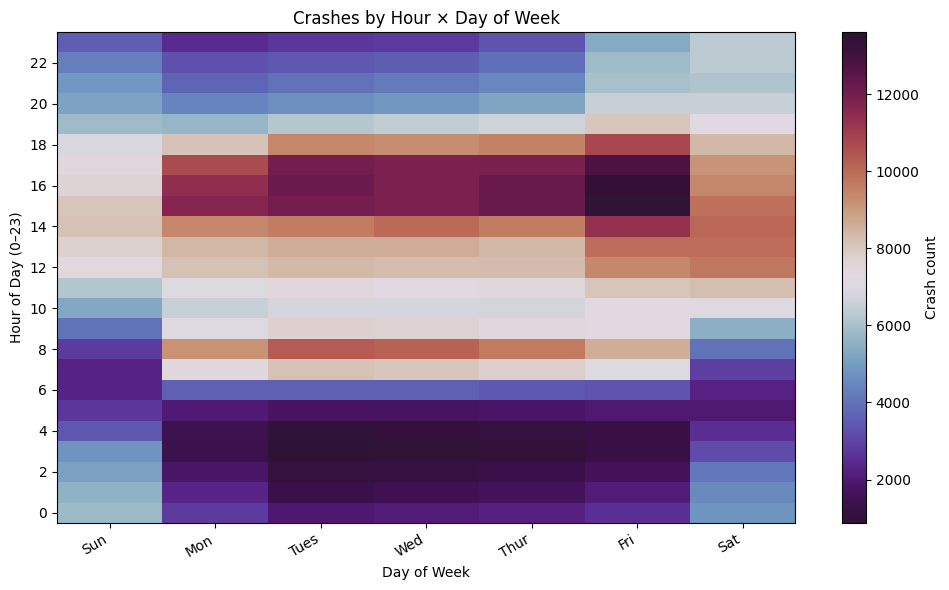

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# Pivot table: counts of crashes
heat_counts = work.pivot_table(
    index="CRASH_HOUR",
    columns="CRASH_DAY_OF_WEEK",
    values="CRASH_DATE",
    aggfunc="count",
    fill_value=0
)

# Day labels (1=Sun ... 7=Sat)
day_labels = ["Sun", "Mon", "Tues", "Wed", "Thur", "Fri", "Sat"]
day_order = [1, 2, 3, 4, 5, 6, 7]

# Reorder columns to match the labels
heat_counts = heat_counts.reindex(columns=day_order)

plt.figure(figsize=(10, 6))
plt.imshow(heat_counts.values, aspect="auto", origin="lower", cmap="twilight_shifted")
plt.colorbar(label="Crash count")

plt.title("Crashes by Hour × Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Hour of Day (0–23)")

# xticks: positions 0..6, labels are your day names
plt.xticks(ticks=np.arange(len(day_labels)), labels=day_labels, rotation=30, ha="right")

# optional: show every 2 hours
plt.yticks(ticks=np.arange(0, 24, 2), labels=np.arange(0, 24, 2))

plt.tight_layout()
plt.show()

In [16]:
# Create Injury Flag
import numpy as np
import matplotlib.pyplot as plt

work = work.copy()
work["HAS_INJURY"] = (work["INJURIES_TOTAL"].fillna(0) >  0).astype(int)

# Pivot to Injury Rate
heat_injury = work.pivot_table(
    index="CRASH_HOUR",
    columns="CRASH_DAY_OF_WEEK",
    values="HAS_INJURY",
    aggfunc="mean",
    fill_value=0
)

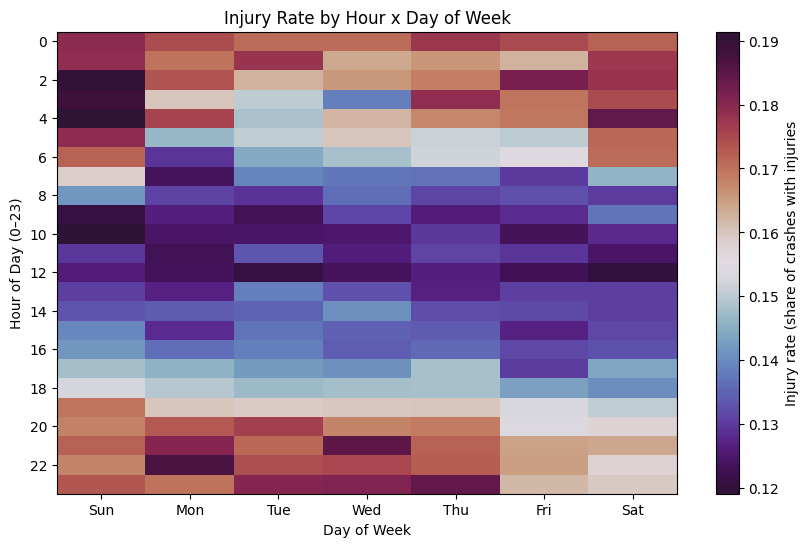

In [55]:
# Plot Graph
plt.figure(figsize=(10,6))
plt.imshow(heat_injury.values, aspect="auto", cmap="twilight_shifted")
plt.colorbar(label="Injury rate (share of crashes with injuries")

plt.title("Injury Rate by Hour x Day of Week")
plt.xlabel("Day of Week")

# Day of the week labels
day_labels = {1:"Sun", 2:"Mon", 3:"Tue", 4:"Wed", 5:"Thu", 6:"Fri", 7:"Sat"}
plt.ylabel("Hour of Day (0–23)")
plt.xticks(np.arange(heat_injury.shape[1]),
           [day_labels.get(d, d) for d in heat_injury.columns])
plt.yticks(np.arange(0, 24, 2), np.arange(0, 24, 2))

plt.show()

In [28]:
# Worst Windows Table (volume + Injury)
worst_windows = (
    work.groupby(["CRASH_DAY_OF_WEEK", "CRASH_HOUR"])
        .agg(
            crashes=("HAS_INJURY", "size"),
            injury_rate=("HAS_INJURY", "mean")
        )
        .reset_index()
)

# "worst" score = crashes * injury rate
worst_windows["score"] = worst_windows["crashes"] * worst_windows["injury_rate"]

# Convert CRASH_DAY_OF_WEEK -> Day Names
day_map = {1:"Sun", 2:"Mon", 3:"Tue", 4:"Wed", 5:"Thu", 6:"Fri", 7:"Sat"}
worst_windows["day"] = worst_windows["CRASH_DAY_OF_WEEK"].map(day_map)

# Convert CRASH_HOUR -> AM/PM labels
def hour_to_ampm(h):
    h = int(h)
    suffix = "AM" if h < 12 else "PM"
    hour12 = h % 12
    hour12 = 12 if hour12 == 0 else hour12
    return f"{hour12}{suffix}"

worst_windows["hour_label"] = worst_windows["CRASH_HOUR"].apply(hour_to_ampm)

# Use readable labels in place of the originals
display_df = worst_windows.copy()
display_df["CRASH_DAY_OF_WEEK"] = display_df["day"]
display_df["CRASH_HOUR"] = display_df["hour_label"]

display_cols = ["CRASH_DAY_OF_WEEK", "CRASH_HOUR", "crashes", "injury_rate", "score"]

(display_df
    .sort_values("score", ascending=False)
    .loc[:, display_cols]
    .head(15)
)

# NOTE: score = crashes * injury_rate

,CRASH_DAY_OF_WEEK,CRASH_HOUR,crashes,injury_rate,score
136,Fri,4PM,13445,0.131647,1770.0
113,Thu,5PM,11897,0.148189,1763.0
135,Fri,3PM,13608,0.126911,1727.0
65,Tue,5PM,12027,0.142430,1713.0
64,Tue,4PM,12178,0.138446,1686.0
89,Wed,5PM,11884,0.140778,1673.0
137,Fri,5PM,12781,0.130193,1664.0
112,Thu,4PM,12249,0.135603,1661.0
63,Tue,3PM,12057,0.137099,1653.0
111,Thu,3PM,12211,0.133896,1635.0
